## **Phase 1 — เตรียมข้อมูล (Data Preparation)**

### **Install Library**

In [47]:
import subprocess
subprocess.run(['pip', 'install', 'seaborn'], check=True)

CompletedProcess(args=['pip', 'install', 'seaborn'], returncode=0)

In [48]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from pyproj import Transformer
from shapely.geometry import Point
import matplotlib as mpl
import matplotlib.font_manager as fm
import urllib.request
import os
import warnings
warnings.filterwarnings('ignore')

In [49]:
# ══════════════════════════════════════════════════════════════════
#  กำหนด Path ทั้งหมดในเซลล์นี้ที่เดียว
#  แก้ BASE_PATH ให้ตรงกับเครื่อง
# ══════════════════════════════════════════════════════════════════

BASE_PATH = r"D:\gistnu\ST-DBSCAN\file_final\Phase 1 Final"

# ── Input ──────────────────────────────────────────────────────────
PATH_ARCHIVE  = r"D:\gistnu\Data-20260414T085329Z-3-001\Data\DL_FIRE_SV-C2_737563\fire_archive_SV-C2_737563.csv"
PATH_NRT      = r"D:\gistnu\Data-20260414T085329Z-3-001\Data\DL_FIRE_SV-C2_737563\fire_nrt_SV-C2_737563.csv"
PATH_HDX_A1   = r"D:\gistnu\tha_admin_boundaries.shp\tha_admin1.shp"
PATH_HDX_A2   = r"D:\gistnu\tha_admin_boundaries.shp\tha_admin2.shp"
PATH_LANDUSE  = r"D:\gistnu\Data\Landuse_พิษณุโลก_2564\LU_PLK_2564.shp"

# ── Output ─────────────────────────────────────────────────────────
import os
PLOT_DIR    = os.path.join(BASE_PATH, "plots")
PATH_OUTPUT = os.path.join(BASE_PATH, "hotspot_final.gpkg")
os.makedirs(PLOT_DIR, exist_ok=True)

print(f"✓ BASE_PATH  : {BASE_PATH}")
print(f"✓ PLOT_DIR   : {PLOT_DIR}")
print(f"✓ PATH_OUTPUT: {PATH_OUTPUT}")


✓ BASE_PATH  : D:\gistnu\ST-DBSCAN\file_final\Phase 1 Final
✓ PLOT_DIR   : D:\gistnu\ST-DBSCAN\file_final\Phase 1 Final\plots
✓ PATH_OUTPUT: D:\gistnu\ST-DBSCAN\file_final\Phase 1 Final\hotspot_final.gpkg


### **โหลดข้อมูลดิบและตรวจสอบเบื้องต้น**

In [50]:
df_archive = pd.read_csv(PATH_ARCHIVE)
df_nrt     = pd.read_csv(PATH_NRT)

In [51]:
print(f"Archive : {len(df_archive):,} แถว | {df_archive.shape[1]} columns")
print(f"NRT     : {len(df_nrt):,} แถว | {df_nrt.shape[1]} columns")
print(f"\nColumns Archive : {list(df_archive.columns)}")
print(f"Columns NRT     : {list(df_nrt.columns)}")

Archive : 101,385 แถว | 15 columns
NRT     : 7,891 แถว | 14 columns

Columns Archive : ['latitude', 'longitude', 'brightness', 'scan', 'track', 'acq_date', 'acq_time', 'satellite', 'instrument', 'confidence', 'version', 'bright_t31', 'frp', 'daynight', 'type']
Columns NRT     : ['latitude', 'longitude', 'brightness', 'scan', 'track', 'acq_date', 'acq_time', 'satellite', 'instrument', 'confidence', 'version', 'bright_t31', 'frp', 'daynight']


In [52]:
df_archive.head()

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type
0,17.55117,100.24280,331.02,0.41,0.45,2020-01-01,654,N,VIIRS,n,2,298.50,3.12,D,0
1,16.73990,99.68476,349.36,0.55,0.43,2020-01-01,654,N,VIIRS,n,2,300.59,12.40,D,0
2,16.74911,99.69405,335.89,0.55,0.43,2020-01-01,654,N,VIIRS,n,2,299.73,5.27,D,0
3,16.12347,100.35069,338.93,0.40,0.44,2020-01-01,654,N,VIIRS,n,2,299.30,2.72,D,0
4,16.81365,100.13860,336.63,0.39,0.44,2020-01-01,654,N,VIIRS,n,2,299.19,3.06,D,0


In [53]:
df_nrt.head()

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight
0,16.04274,100.48558,336.57,0.41,0.45,2026-01-01,701,N,VIIRS,n,2.0NRT,304.19,2.00,D
1,16.20435,100.19859,340.16,0.40,0.44,2026-01-01,701,N,VIIRS,n,2.0NRT,301.34,3.56,D
2,16.54722,100.40638,342.28,0.42,0.45,2026-01-01,701,N,VIIRS,n,2.0NRT,305.54,5.12,D
3,17.61101,100.14038,331.08,0.41,0.45,2026-01-01,701,N,VIIRS,n,2.0NRT,302.63,3.42,D
4,17.92728,101.09950,331.61,0.48,0.48,2026-01-01,701,N,VIIRS,n,2.0NRT,297.66,2.26,D


In [54]:
print("\n[CHECKPOINT A] ตรวจสอบการโหลด")
assert len(df_archive) > 0, "✗ Archive ว่างเปล่า"
assert len(df_nrt) > 0,     "✗ NRT ว่างเปล่า"
assert 'latitude'   in df_archive.columns, "✗ ไม่มี column latitude"
assert 'longitude'  in df_archive.columns, "✗ ไม่มี column longitude"
assert 'frp'        in df_archive.columns, "✗ ไม่มี column frp"
assert 'acq_date'   in df_archive.columns, "✗ ไม่มี column acq_date"
assert 'confidence' in df_archive.columns, "✗ ไม่มี column confidence"
print("✓ โหลดไฟล์ทั้งสองสำเร็จ columns ครบถ้วน")


[CHECKPOINT A] ตรวจสอบการโหลด
✓ โหลดไฟล์ทั้งสองสำเร็จ columns ครบถ้วน


### **Data Quality Check**

In [55]:
for name, df_check in [("Archive", df_archive), ("NRT", df_nrt)]:
    print(f"\n--- {name} ---")

    df_check['acq_date'] = pd.to_datetime(df_check['acq_date'])

    # 1. Missing values
    missing = df_check.isnull().sum()
    missing_pct = (missing / len(df_check) * 100).round(2)
    missing_df = pd.DataFrame({'count': missing, '%': missing_pct})
    missing_df = missing_df[missing_df['count'] > 0]
    if len(missing_df) == 0:
        print("Missing values  : ไม่พบ")
    else:
        print(f"Missing values  :\n{missing_df.to_string()}")

    # 2. Duplicate
    dup = df_check.duplicated(
        subset=['latitude', 'longitude', 'acq_date', 'acq_time']
    ).sum()
    print(f"Duplicate rows  : {dup:,} แถว")

    # 3. Date range
    print(f"Date range      : {df_check['acq_date'].min().date()} "
          f"ถึง {df_check['acq_date'].max().date()}")

    # 4. Lat/Lon
    lat_bad = (~df_check['latitude'].between(-90, 90)).sum()
    lon_bad = (~df_check['longitude'].between(-180, 180)).sum()
    print(f"Lat นอกช่วง    : {lat_bad:,} แถว")
    print(f"Lon นอกช่วง    : {lon_bad:,} แถว")

    # 5. FRP
    frp_neg  = (df_check['frp'] <= 0).sum()
    frp_null = df_check['frp'].isnull().sum()
    frp_out  = (df_check['frp'] > 10000).sum()
    print(f"FRP range       : {df_check['frp'].min():.2f} - {df_check['frp'].max():.2f} MW")
    print(f"FRP <= 0        : {frp_neg:,} | FRP null: {frp_null:,} | FRP > 10,000: {frp_out:,}")

    # 6. Brightness
    bt_low = (df_check['brightness'] < 300).sum()
    print(f"Brightness range: {df_check['brightness'].min():.2f} - {df_check['brightness'].max():.2f} K")
    print(f"Brightness < 300: {bt_low:,} แถว")

    # 7. Confidence
    print(f"Confidence:\n{df_check['confidence'].value_counts().to_string()}")

    # 8. Type (Archive only)
    if 'type' in df_check.columns:
        print(f"Type:\n{df_check['type'].value_counts().to_string()}")

    # 9. Daynight
    print(f"Day/Night:\n{df_check['daynight'].value_counts().to_string()}")


--- Archive ---
Missing values  : ไม่พบ
Duplicate rows  : 0 แถว
Date range      : 2020-01-01 ถึง 2025-12-31
Lat นอกช่วง    : 0 แถว
Lon นอกช่วง    : 0 แถว
FRP range       : 0.11 - 340.05 MW
FRP <= 0        : 0 | FRP null: 0 | FRP > 10,000: 0
Brightness range: 208.00 - 367.00 K
Brightness < 300: 1,351 แถว
Confidence:
confidence
n    89784
l     9808
h     1793
Type:
type
0    101262
3        62
2        61
Day/Night:
daynight
D    64597
N    36788

--- NRT ---
Missing values  : ไม่พบ
Duplicate rows  : 0 แถว
Date range      : 2026-01-01 ถึง 2026-04-08
Lat นอกช่วง    : 0 แถว
Lon นอกช่วง    : 0 แถว
FRP range       : 0.15 - 263.04 MW
FRP <= 0        : 0 | FRP null: 0 | FRP > 10,000: 0
Brightness range: 208.00 - 367.00 K
Brightness < 300: 37 แถว
Confidence:
confidence
n    6816
l     962
h     113
Day/Night:
daynight
D    4074
N    3817


In [56]:
print("\n[CHECKPOINT B] ตรวจสอบ Data Quality")
for name, df_check in [("Archive", df_archive), ("NRT", df_nrt)]:
    assert df_check['latitude'].between(-90, 90).all(), \
        f"✗ {name}: มีค่า latitude นอกช่วง"
    assert df_check['longitude'].between(-180, 180).all(), \
        f"✗ {name}: มีค่า longitude นอกช่วง"
print("✓ ค่า lat/lon อยู่ในช่วงที่ถูกต้องทั้งสองไฟล์")


[CHECKPOINT B] ตรวจสอบ Data Quality
✓ ค่า lat/lon อยู่ในช่วงที่ถูกต้องทั้งสองไฟล์


### **Exploratory Data Analysis**

In [ ]:
# ── ตั้งค่าฟอนต์ภาษาไทยสำหรับ Matplotlib ───────────────────────────────────
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'TH Sarabun New'
plt.rcParams['axes.unicode_minus'] = False

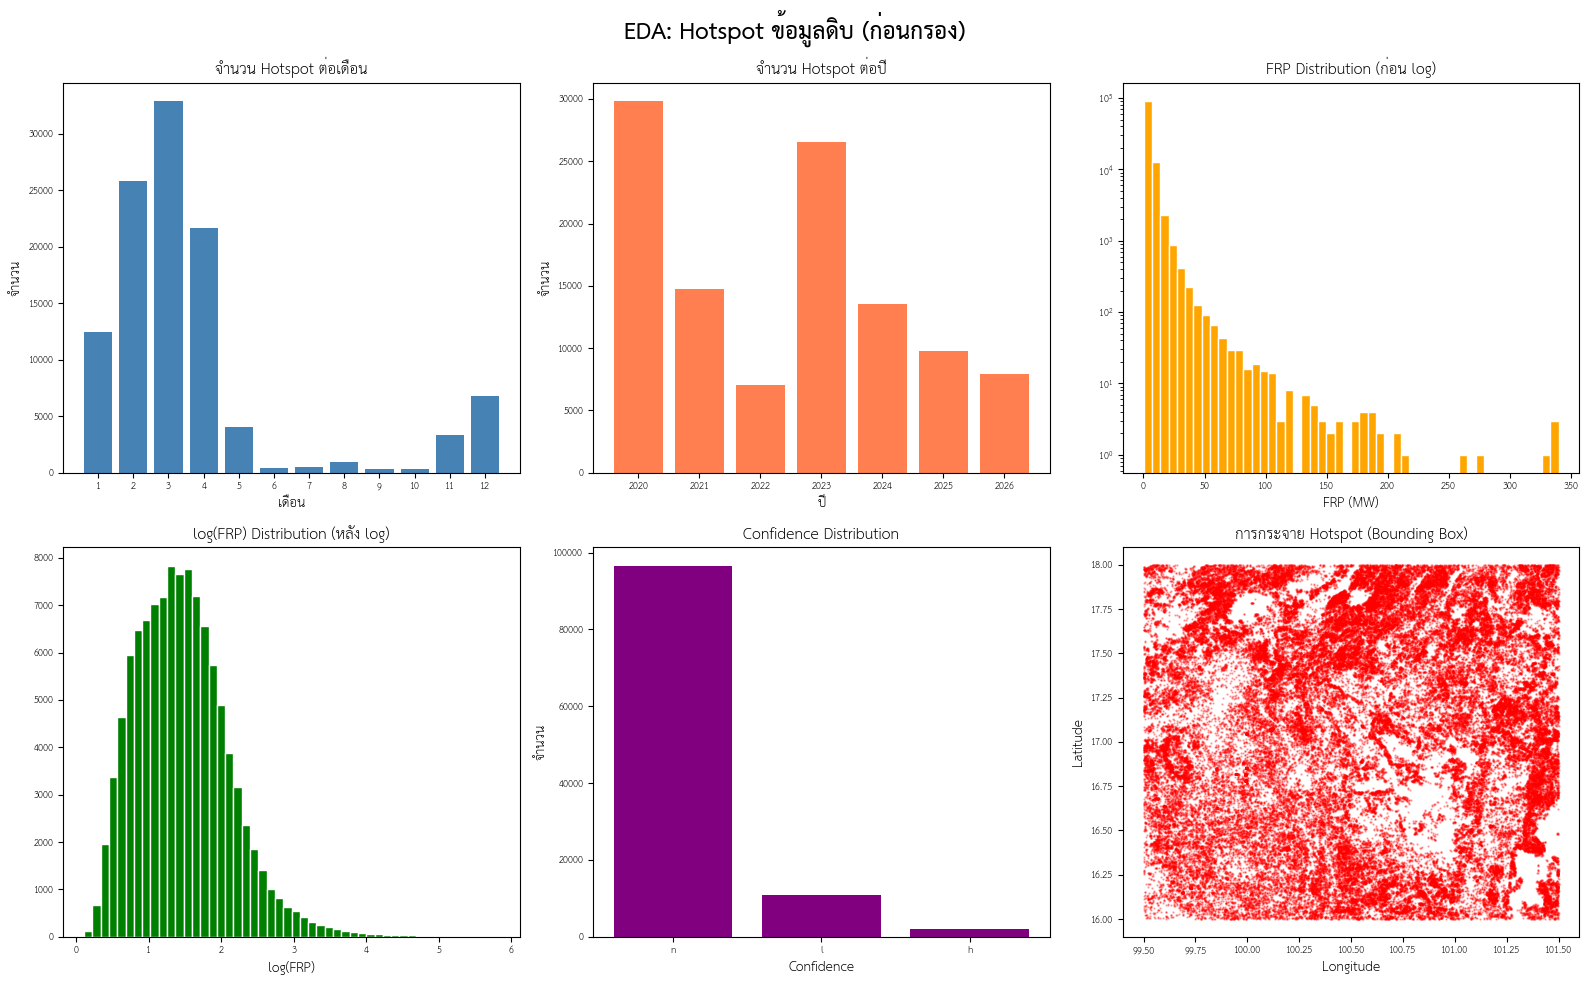

In [58]:
# รวมชั่วคราวเพื่อดู pattern
df_nrt['type'] = 0
df_raw = pd.concat([df_archive, df_nrt], ignore_index=True)
df_raw['acq_date'] = pd.to_datetime(df_raw['acq_date'])
df_raw['month'] = df_raw['acq_date'].dt.month
df_raw['year']  = df_raw['acq_date'].dt.year

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('EDA: Hotspot ข้อมูลดิบ (ก่อนกรอง)', fontsize=24, fontweight='bold')

# 1. Hotspot ต่อเดือน
month_counts = df_raw['month'].value_counts().sort_index()
axes[0,0].bar(month_counts.index, month_counts.values, color='steelblue')
axes[0,0].set_title('จำนวน Hotspot ต่อเดือน', fontsize=16)
axes[0,0].set_xlabel('เดือน', fontsize=14)
axes[0,0].set_ylabel('จำนวน', fontsize=14)
axes[0,0].set_xticks(range(1, 13))

# 2. Hotspot ต่อปี
year_counts = df_raw['year'].value_counts().sort_index()
axes[0,1].bar(year_counts.index, year_counts.values, color='coral')
axes[0,1].set_title('จำนวน Hotspot ต่อปี', fontsize=16)
axes[0,1].set_xlabel('ปี', fontsize=14)
axes[0,1].set_ylabel('จำนวน', fontsize=14)

# 3. FRP distribution (ก่อน log)
axes[0,2].hist(df_raw['frp'], bins=50, color='orange', edgecolor='white')
axes[0,2].set_title('FRP Distribution (ก่อน log)', fontsize=16)
axes[0,2].set_xlabel('FRP (MW)', fontsize=14)
axes[0,2].set_yscale('log')

# 4. log(FRP) distribution
axes[1,0].hist(np.log1p(df_raw['frp']), bins=50, color='green', edgecolor='white')
axes[1,0].set_title('log(FRP) Distribution (หลัง log)', fontsize=16)
axes[1,0].set_xlabel('log(FRP)', fontsize=14)

# 5. Confidence distribution
conf_counts = df_raw['confidence'].value_counts()
axes[1,1].bar(conf_counts.index, conf_counts.values, color='purple')
axes[1,1].set_title('Confidence Distribution', fontsize=16)
axes[1,1].set_xlabel('Confidence', fontsize=14)
axes[1,1].set_ylabel('จำนวน', fontsize=14)

# 6. Scatter lat/lon ดูการกระจาย
axes[1,2].scatter(df_raw['longitude'], df_raw['latitude'],
                  s=0.5, alpha=0.3, color='red')
axes[1,2].set_title('การกระจาย Hotspot (Bounding Box)', fontsize=16)
axes[1,2].set_xlabel('Longitude', fontsize=14)
axes[1,2].set_ylabel('Latitude', fontsize=14)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'eda_hotspot.png'), dpi=150, bbox_inches='tight')
plt.show()


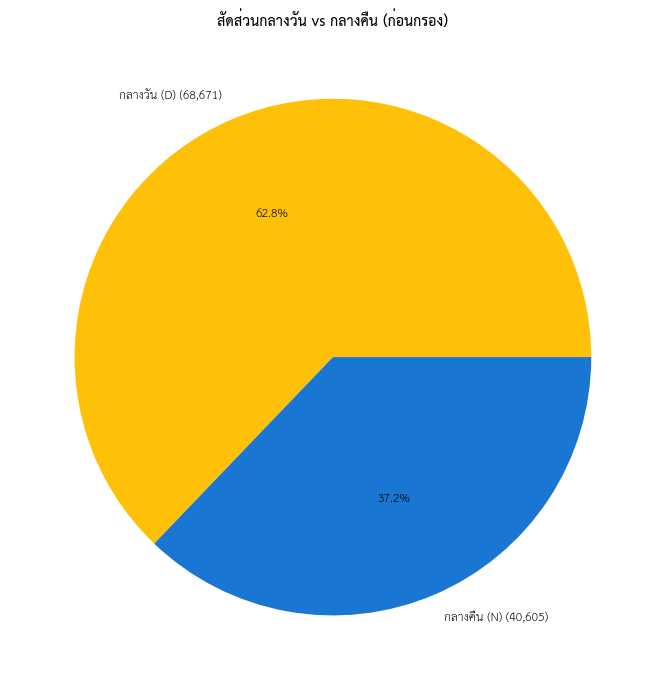

✓ กราฟ Day/Night ก่อนกรองสำเร็จ


In [59]:
# ─── กราฟ Day/Night ก่อนกรอง ─────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))
dn_raw = df_raw['daynight'].value_counts()
ax.pie(dn_raw.values,
       labels=[f"{'กลางวัน (D)' if d=='D' else 'กลางคืน (N)'} ({v:,})" for d, v in dn_raw.items()],
       autopct='%1.1f%%', colors=['#FFC107','#1976D2'],
       textprops={'fontsize':13})
ax.set_title('สัดส่วนกลางวัน vs กลางคืน (ก่อนกรอง)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'daynight_raw.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✓ กราฟ Day/Night ก่อนกรองสำเร็จ")

In [60]:
print("\n[CHECKPOINT C] ตรวจสอบ EDA")
print(f"✓ รวมข้อมูลดิบ: {len(df_raw):,} แถว")
print(f"✓ ช่วงปี: {df_raw['year'].min()} - {df_raw['year'].max()}")
print(f"✓ เดือนที่มี hotspot มากสุด: เดือน {month_counts.idxmax()} "
      f"({month_counts.max():,} จุด)")
print("✓ บันทึกกราฟ EDA สำเร็จ → eda_raw.png")
print("\n** ตรวจสอบกราฟก่อนไปต่อ: เดือนไหนมี hotspot มากสุด? **")
print("** ใช้ผลนี้ปรับ burn_season ใน STEP 3 ให้สอดคล้องกับข้อมูลจริง **")


[CHECKPOINT C] ตรวจสอบ EDA
✓ รวมข้อมูลดิบ: 109,276 แถว
✓ ช่วงปี: 2020 - 2026
✓ เดือนที่มี hotspot มากสุด: เดือน 3 (32,853 จุด)
✓ บันทึกกราฟ EDA สำเร็จ → eda_raw.png

** ตรวจสอบกราฟก่อนไปต่อ: เดือนไหนมี hotspot มากสุด? **
** ใช้ผลนี้ปรับ burn_season ใน STEP 3 ให้สอดคล้องกับข้อมูลจริง **


### **STEP 1 — ทำความสะอาดข้อมูล**

In [61]:
df = df_raw.copy()
print(f"เริ่มต้น: {len(df):,} แถว")

# 1 ลบ duplicate
before = len(df)
df = df.drop_duplicates(subset=['latitude', 'longitude', 'acq_date', 'acq_time'])
print(f"ลบ duplicate: เหลือ {len(df):,} แถว (ลบออก {before-len(df):,})")

# 2 ลบ lat/lon ผิดปกติ
before = len(df)
df = df[df['latitude'].between(-90, 90) & df['longitude'].between(-180, 180)]
print(f"ลบพิกัดผิดปกติ: เหลือ {len(df):,} แถว (ลบออก {before-len(df):,})")

# 3 ลบ FRP <= 0 หรือ null
before = len(df)
df = df[df['frp'] > 0]
df = df[df['frp'].notna()]
print(f"ลบ FRP <= 0 / null: เหลือ {len(df):,} แถว (ลบออก {before-len(df):,})")

# 4 กรอง confidence >= nominal
before = len(df)
df = df[df['confidence'].isin(['n', 'h', 'nominal', 'high'])]
print(f"กรอง confidence (n/h): เหลือ {len(df):,} แถว (ลบออก {before-len(df):,})")

# 5 กรอง type == 0 (vegetation fire)
before = len(df)
df = df[df['type'] == 0]
print(f"กรอง type==0: เหลือ {len(df):,} แถว (ลบออก {before-len(df):,})")

เริ่มต้น: 109,276 แถว
ลบ duplicate: เหลือ 109,276 แถว (ลบออก 0)
ลบพิกัดผิดปกติ: เหลือ 109,276 แถว (ลบออก 0)
ลบ FRP <= 0 / null: เหลือ 109,276 แถว (ลบออก 0)
กรอง confidence (n/h): เหลือ 98,506 แถว (ลบออก 10,770)
กรอง type==0: เหลือ 98,386 แถว (ลบออก 120)


In [62]:
print("\n[CHECKPOINT 1] ตรวจสอบหลังกรอง")
assert len(df) > 0,                                    "✗ ไม่มีข้อมูลเหลือหลังกรอง"
assert df['frp'].min() > 0,                            "✗ ยังมี FRP <= 0 หลงเหลือ"
assert df['confidence'].isin(['n','h','nominal','high']).all(), \
                                                       "✗ ยังมี confidence ต่ำหลงเหลือ"
assert df['type'].eq(0).all(),                         "✗ ยังมี type != 0 หลงเหลือ"
assert df.duplicated(subset=['latitude','longitude','acq_date','acq_time']).sum() == 0, \
                                                       "✗ ยังมี duplicate หลงเหลือ"
print("✓ ไม่มี duplicate")
print("✓ FRP > 0 ทุกแถว")
print("✓ confidence เป็น n/h ทุกแถว")
print("✓ type == 0 ทุกแถว")
print(f"✓ จำนวนแถวหลังกรอง: {len(df):,}")


[CHECKPOINT 1] ตรวจสอบหลังกรอง
✓ ไม่มี duplicate
✓ FRP > 0 ทุกแถว
✓ confidence เป็น n/h ทุกแถว
✓ type == 0 ทุกแถว
✓ จำนวนแถวหลังกรอง: 98,386


### **STEP 2 — Clip ให้เหลือแค่พิษณุโลก**

In [63]:
hdx1 = gpd.read_file(PATH_HDX_A1)
print(f"✓ โหลดขอบเขตจังหวัด: {len(hdx1)} features | CRS: {hdx1.crs}")

✓ โหลดขอบเขตจังหวัด: 77 features | CRS: EPSG:4326


In [64]:
phitsanulok_boundary = hdx1[hdx1['adm1_name'] == 'Phitsanulok'].copy()
print(f"✓ Bounding box พิษณุโลก: {phitsanulok_boundary.total_bounds.round(4)}")

✓ Bounding box พิษณุโลก: [ 99.8534  16.3188 101.11    17.7437]


In [65]:
geometry = [Point(lon, lat) for lon, lat in zip(df['longitude'], df['latitude'])]
gdf = gpd.GeoDataFrame(df, geometry=geometry, crs='EPSG:4326')

In [66]:
before = len(gdf)
gdf = gpd.sjoin(
    gdf,
    phitsanulok_boundary[['adm1_name', 'geometry']],
    how='inner',
    predicate='within'
)
gdf = gdf.drop(columns=['index_right'])
print(f"clip เหลือ : {len(gdf):,} จุด (ลบออก {before-len(gdf):,} จุดนอกพิษณุโลก)")

clip เหลือ : 16,292 จุด (ลบออก 82,094 จุดนอกพิษณุโลก)


In [67]:
print("\n[CHECKPOINT 2] ตรวจสอบ Clip")
assert len(gdf) > 0, "✗ ไม่มีจุดในพิษณุโลกเลย"

# ตรวจ lat/lon อยู่ในกรอบพิษณุโลกจริง
bounds = phitsanulok_boundary.total_bounds  # [minx, miny, maxx, maxy]
lat_in = gdf['latitude'].between(bounds[1], bounds[3])
lon_in = gdf['longitude'].between(bounds[0], bounds[2])
print(f"✓ จุดในกรอบ Bounding Box: {(lat_in & lon_in).sum():,} จุด")


[CHECKPOINT 2] ตรวจสอบ Clip
✓ จุดในกรอบ Bounding Box: 16,292 จุด


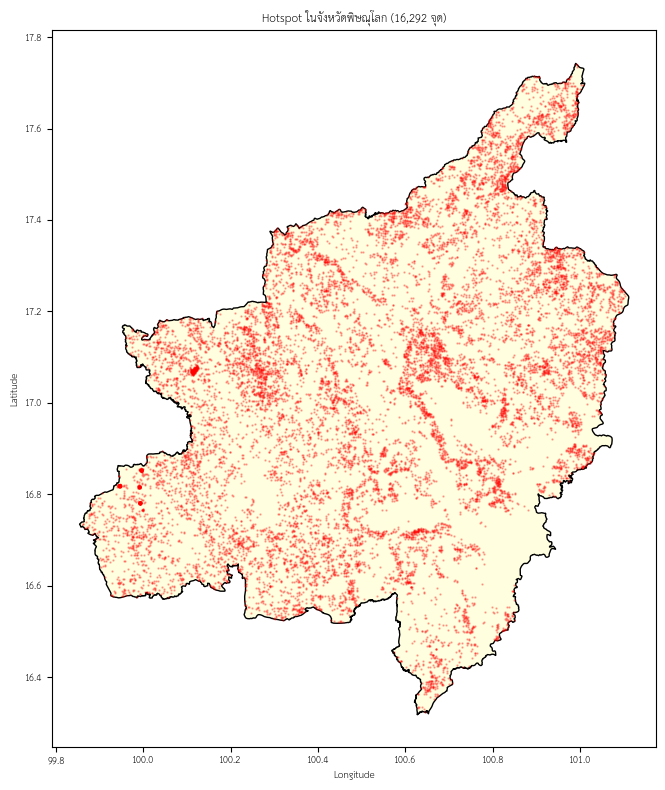

✓ Plot ตรวจสอบสำเร็จ → checkpoint2_clip.png
** ตรวจสอบภาพ: จุดแดงควรอยู่ในขอบเขตจังหวัดพิษณุโลกเท่านั้น **


In [68]:
fig, ax = plt.subplots(figsize=(8, 8))
phitsanulok_boundary.plot(ax=ax, color='lightyellow', edgecolor='black', linewidth=1)
gdf.plot(ax=ax, color='red', markersize=0.5, alpha=0.3)
ax.set_title(f'Hotspot ในจังหวัดพิษณุโลก ({len(gdf):,} จุด)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'hotspot_phitsanulok.png'), dpi=150)
plt.show()
print("✓ Plot ตรวจสอบสำเร็จ → checkpoint2_clip.png")
print("** ตรวจสอบภาพ: จุดแดงควรอยู่ในขอบเขตจังหวัดพิษณุโลกเท่านั้น **")

### **STEP 3 — สร้าง Features**

In [69]:
transformer = Transformer.from_crs("EPSG:4326", "EPSG:32647", always_xy=True)
gdf['x_utm'], gdf['y_utm'] = transformer.transform(
    gdf['longitude'].values, gdf['latitude'].values)
print(f"x_utm range: {gdf['x_utm'].min():.0f} - {gdf['x_utm'].max():.0f} m")
print(f"y_utm range: {gdf['y_utm'].min():.0f} - {gdf['y_utm'].max():.0f} m")

x_utm range: 591818 - 723516 m
y_utm range: 1805469 - 1962645 m


In [70]:
ref_date = pd.Timestamp('2020-01-01')
gdf['t_days'] = (gdf['acq_date'] - ref_date).dt.days
print(f"t_days range: {gdf['t_days'].min()} - {gdf['t_days'].max()} วัน")

t_days range: 0 - 2289 วัน


In [71]:
gdf['month']     = gdf['acq_date'].dt.month
gdf['month_sin'] = np.sin(2 * np.pi * gdf['month'] / 12)
gdf['month_cos'] = np.cos(2 * np.pi * gdf['month'] / 12)
print(f"month_sin range: {gdf['month_sin'].min():.4f} - {gdf['month_sin'].max():.4f}")
print(f"month_cos range: {gdf['month_cos'].min():.4f} - {gdf['month_cos'].max():.4f}")

month_sin range: -1.0000 - 1.0000
month_cos range: -1.0000 - 1.0000


In [72]:
def classify_burn_season(month):
    if month in [2, 3, 4]:
        return 'peak_burn'        # ช่วงเผาสูงสุด (กพ-เมย)
    elif month in [1, 5]:
        return 'early_late_burn'  # ช่วงต้น/ปลายฤดู (มค, พค)
    elif month in [11, 12]:
        return 'pre_season'       # ก่อนฤดูเผา (พย-ธค)
    else:
        return 'off_season'       # นอกฤดู

gdf['burn_season'] = gdf['month'].apply(classify_burn_season)
print("burn_season distribution:")
print(gdf['burn_season'].value_counts().to_string())

burn_season distribution:
burn_season
peak_burn          11158
early_late_burn     2530
pre_season          2028
off_season           576


In [73]:
gdf['log_frp'] = np.log1p(gdf['frp'])
print(f"\nlog_frp range: {gdf['log_frp'].min():.2f} - {gdf['log_frp'].max():.2f}")


log_frp range: 0.13 - 5.00


In [74]:
print("\n[CHECKPOINT 3] ตรวจสอบ Features")
assert gdf['x_utm'].notna().all(),     "✗ x_utm มี null"
assert gdf['y_utm'].notna().all(),     "✗ y_utm มี null"
assert gdf['t_days'].min() >= 0,       "✗ t_days มีค่าติดลบ"
assert gdf['month_sin'].between(-1, 1).all(), "✗ month_sin นอกช่วง [-1, 1]"
assert gdf['month_cos'].between(-1, 1).all(), "✗ month_cos นอกช่วง [-1, 1]"
assert gdf['log_frp'].min() >= 0,      "✗ log_frp มีค่าติดลบ"
assert gdf['burn_season'].isin(['peak_burn', 'early_late_burn', 'pre_season', 'off_season']).all(), "✗ burn_season มีค่านอกที่กำหนด"


[CHECKPOINT 3] ตรวจสอบ Features


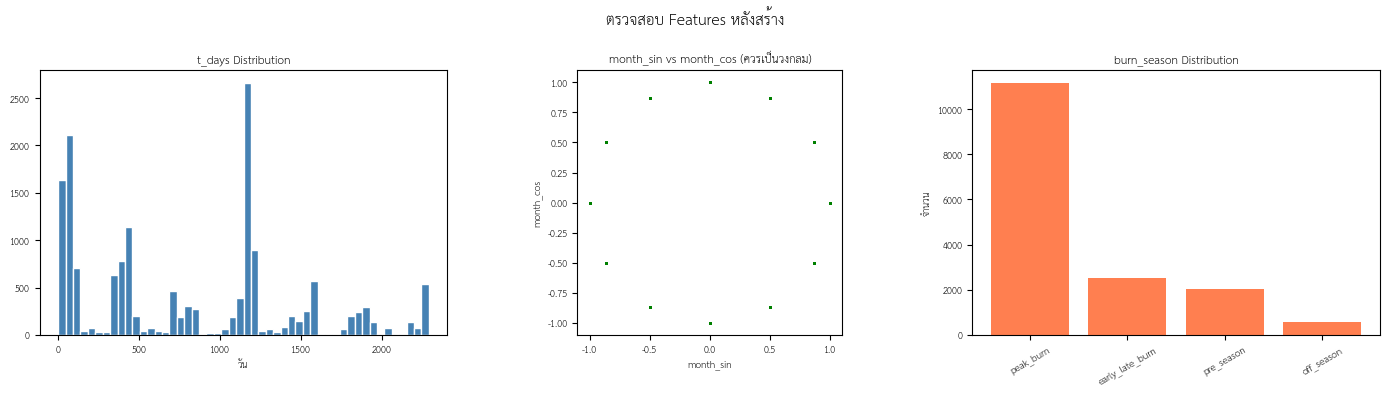

✓ ตรวจสอบ features ผ่านทุกรายการ
** ตรวจสอบภาพ: month_sin vs month_cos ควรกระจายเป็นวงกลม **


In [75]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('ตรวจสอบ Features หลังสร้าง', fontsize=16)

axes[0].hist(gdf['t_days'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('t_days Distribution')
axes[0].set_xlabel('วัน')

axes[1].scatter(gdf['month_sin'], gdf['month_cos'], s=1, alpha=0.2, color='green')
axes[1].set_title('month_sin vs month_cos (ควรเป็นวงกลม)')
axes[1].set_xlabel('month_sin')
axes[1].set_ylabel('month_cos')
axes[1].set_aspect('equal')

burn_counts = gdf['burn_season'].value_counts()
axes[2].bar(burn_counts.index, burn_counts.values, color='coral')
axes[2].set_title('burn_season Distribution')
axes[2].set_ylabel('จำนวน')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'features.png'), dpi=150)
plt.show()
print("✓ ตรวจสอบ features ผ่านทุกรายการ")
print("** ตรวจสอบภาพ: month_sin vs month_cos ควรกระจายเป็นวงกลม **")

### **STEP 4 — Spatial Join กับ Land Use**

In [76]:
landuse = gpd.read_file(PATH_LANDUSE)
print(f"Land Use: {len(landuse):,} polygons | CRS: {landuse.crs}")

Land Use: 73,709 polygons | CRS: EPSG:32647


In [77]:
# ตรวจ missing ใน Land Use
lu_missing = landuse[['LU_CODE', 'LU_DES_TH', 'LUL1_CODE']].isnull().sum()
print(f"Missing ใน Land Use:\n{lu_missing.to_string()}")

Missing ใน Land Use:
LU_CODE      0
LU_DES_TH    0
LUL1_CODE    0


In [78]:
# แปลง hotspot เป็น UTM ให้ตรงกับ Land Use
gdf_utm = gdf.to_crs('EPSG:32647')

In [79]:
before = len(gdf_utm)

# ลบ land use columns เก่าออกก่อนถ้ามี
lu_cols = ['LU_CODE', 'LU_DES_TH', 'LUL1_CODE', 'LUL2_CODE', 'index_right']
gdf_utm = gdf_utm.drop(columns=[c for c in lu_cols if c in gdf_utm.columns], errors='ignore')

gdf_temp = gpd.sjoin(
    gdf_utm,
    landuse[['LU_CODE', 'LU_DES_TH', 'LUL1_CODE', 'geometry']],
    how='left',
    predicate='within'
)

dup_idx = gdf_temp.index[gdf_temp.index.duplicated(keep=False)]

if len(dup_idx) > 0:
    print(f"พบจุดที่ตกใน polygon ซ้อนทับ: {len(dup_idx.unique()):,} จุด")
    gdf_dup = gdf_utm.loc[dup_idx.unique()]
    gdf_nearest = gpd.sjoin_nearest(
        gdf_dup,
        landuse[['LU_CODE', 'LU_DES_TH', 'LUL1_CODE', 'geometry']],
        how='left'
    )
    # ถ้า sjoin_nearest ทำให้ชื่อ column ซ้ำ (_left/_right) ให้ใช้ฝั่ง right
    for col in ['LU_CODE', 'LU_DES_TH', 'LUL1_CODE']:
        if f'{col}_left' in gdf_nearest.columns:
            gdf_nearest = gdf_nearest.drop(columns=[f'{col}_left'])
            gdf_nearest = gdf_nearest.rename(columns={f'{col}_right': col})
    gdf_nearest = gdf_nearest[~gdf_nearest.index.duplicated(keep='first')]

    gdf_normal = gdf_temp[~gdf_temp.index.duplicated(keep=False)]
    gdf_utm = pd.concat([gdf_normal, gdf_nearest]).sort_index()
else:
    gdf_utm = gdf_temp[~gdf_temp.index.duplicated(keep='first')]

gdf_utm = gdf_utm.drop(columns=['index_right'], errors='ignore')

no_join = gdf_utm['LUL1_CODE'].isnull().sum()
print(f"Hotspot ที่ join Land Use ไม่ได้: {no_join:,} จุด ({no_join/len(gdf_utm)*100:.1f}%)")

Hotspot ที่ join Land Use ไม่ได้: 35 จุด (0.2%)


In [ ]:
# ── 4a. จำแนกพื้นที่ (fire_type) ──────────────────────────────────────────
# ยึด LUL1_CODE เป็นหลัก และกู้ "พื้นที่ลุ่ม+นาข้าว" ที่ LDD จัดเป็น other
# เนื่องจากจัดลำดับชั้นตามสภาพภูมิประเทศ ทั้งที่จริงคือนาข้าวที่ทำเกษตร

RECOVER_TO_AGRI = ['พื้นที่ลุ่ม+นาข้าว']   # เกณฑ์ชัดเจน ทำซ้ำได้

def classify_fire_type(row):
    if row['LUL1_CODE'] == 'A':
        return 'agricultural'
    if row['LUL1_CODE'] == 'F':
        return 'forest'
    if str(row['LU_DES_TH']) in RECOVER_TO_AGRI:
        return 'agricultural'   # กู้นาข้าวที่ถูกจัดเป็นที่ลุ่ม
    return 'other'

gdf_utm['land_use_type'] = gdf_utm['LU_DES_TH'].fillna('ไม่ทราบ')
gdf_utm['fire_type']     = gdf_utm.apply(classify_fire_type, axis=1)
gdf_utm['is_agri']       = gdf_utm['fire_type'] == 'agricultural'
gdf_utm['is_forest']     = gdf_utm['fire_type'] == 'forest'

# ── 4b. จำแนกชนิดแบบละเอียด (fire_type_detail) ──────────────────────
# map จาก LU_DES_TH → รหัสพืช (เฉพาะ agri/forest — other ไม่เข้า Phase 2/3)
DETAIL_MAP = {
    'agri_paddy'      : ['นาข้าว', 'พื้นที่ลุ่ม+นาข้าว'],
    'agri_sugarcane'  : ['อ้อย'],
    'agri_corn'       : ['ข้าวโพด'],
    'agri_cassava'    : ['มันสำปะหลัง'],
    'agri_perennial'  : ['สัก', 'ยูคาลิปตัส', 'ยางพารา'],
    'agri_orchard'    : ['กล้วย', 'มะม่วง', 'มะม่วง/กล้วย', 'ส้ม/มะม่วง',
                         'มะปราง มะยงชิด', 'มะละกอ'],
    'agri_mixed'      : ['นาข้าว+ข้าวโพด', 'นาข้าว+อ้อย', 'พืชผัก'],
    'agri_abandoned'  : ['นาร้าง', 'ไร่ร้าง', 'ไม้ผลร้าง/เสื่อมโทรม',
                         'ไม้ยืนต้นร้าง/เสื่อมโทรม'],
    'agri_other'      : ['สถานที่เพาะเลี้ยงปลา', 'โรงเรือนเลี้ยงสัตว์ปีก',
                         'โรงเรือนเลี้ยงสุกร'],
    'forest_deciduous': ['ป่าผลัดใบสมบูรณ์', 'ป่าผลัดใบรอสภาพฟื้นฟู'],
}
LU_TO_DETAIL = {lu: d for d, lus in DETAIL_MAP.items() for lu in lus}

def classify_fire_type_detail(row):
    if row['fire_type'] == 'other':
        return 'other'
    detail = LU_TO_DETAIL.get(str(row['LU_DES_TH']))
    if detail:
        return detail
    return 'agri_unspecified' if row['fire_type'] == 'agricultural' else 'forest_unspecified'

gdf_utm['fire_type_detail'] = gdf_utm.apply(classify_fire_type_detail, axis=1)

# ── สรุป ──────────────────────────────────────────────────────────────────────
print(f"เกษตร (agricultural) : {gdf_utm['is_agri'].sum():,} จุด ({gdf_utm['is_agri'].mean()*100:.1f}%)")
print(f"ป่า (forest)         : {gdf_utm['is_forest'].sum():,} จุด ({gdf_utm['is_forest'].mean()*100:.1f}%)")
print(f"อื่นๆ (other)        : {(gdf_utm['fire_type']=='other').sum():,} จุด")
print("\nfire_type_detail distribution:")
print(gdf_utm['fire_type_detail'].value_counts().to_string())

# ── ตรวจ: 'พื้นที่ลุ่ม+นาข้าว' 331 จุดถูกกู้กลับเป็น agri_paddy ──────────────
chk = gdf_utm[gdf_utm['land_use_type'] == 'พื้นที่ลุ่ม+นาข้าว']
print(f"\n[ตรวจ] 'พื้นที่ลุ่ม+นาข้าว' {len(chk)} จุด → "
      f"fire_type={chk['fire_type'].value_counts().to_dict()} | "
      f"detail={chk['fire_type_detail'].value_counts().to_dict()}")


เกษตร (agricultural) : 7,739 จุด (47.5%)
ป่า (forest)         : 7,680 จุด (47.1%)
อื่นๆ (other)        : 873 จุด

fire_type_detail distribution:
fire_type_detail
forest_deciduous      7009
agri_paddy            4747
other                  873
agri_corn              813
forest_unspecified     671
agri_sugarcane         610
agri_perennial         405
agri_cassava           405
agri_unspecified       375
agri_abandoned         201
agri_orchard           151
agri_mixed              23
agri_other               9

[ตรวจ] 'พื้นที่ลุ่ม+นาข้าว' 334 จุด → fire_type={'agricultural': 334} | detail={'agri_paddy': 334}


In [81]:
print("\n[CHECKPOINT 4] ตรวจสอบ Land Use Join")
assert len(gdf_utm) == before, "✗ จำนวนแถวเปลี่ยนหลัง left join"
join_rate = (1 - no_join/len(gdf_utm)) * 100
print(f"✓ จำนวนแถวคงเดิม: {len(gdf_utm):,}")
print(f"✓ Join rate: {join_rate:.1f}%")
if no_join / len(gdf_utm) > 0.1:
    print(f"⚠ จุดที่ join ไม่ได้เกิน 10% — ควรตรวจสอบ CRS และขอบเขต Land Use")
else:
    print(f"✓ จุดที่ join ไม่ได้ไม่เกิน 10% — ยอมรับได้")


[CHECKPOINT 4] ตรวจสอบ Land Use Join
✓ จำนวนแถวคงเดิม: 16,292
✓ Join rate: 99.8%
✓ จุดที่ join ไม่ได้ไม่เกิน 10% — ยอมรับได้


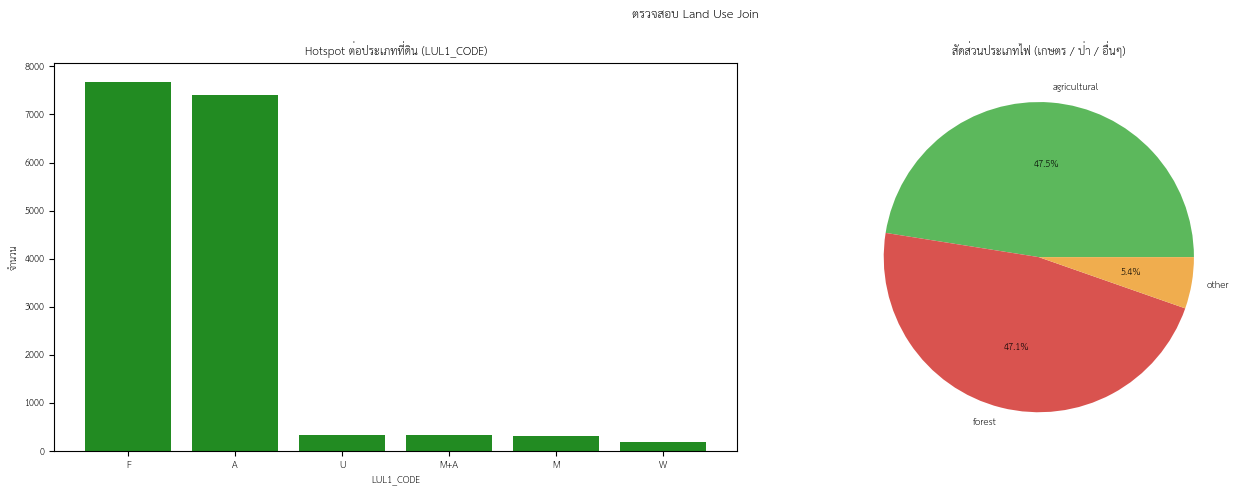

✓ Plot ตรวจสอบ Land Use สำเร็จ → checkpoint4_landuse.png


In [82]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ตรวจสอบ Land Use Join', fontsize=13)

lu_counts = gdf_utm['LUL1_CODE'].value_counts()
axes[0].bar(lu_counts.index, lu_counts.values, color='forestgreen')
axes[0].set_title('Hotspot ต่อประเภทที่ดิน (LUL1_CODE)')
axes[0].set_xlabel('LUL1_CODE')
axes[0].set_ylabel('จำนวน')

# เปลี่ยนเป็น 3 ประเภท
fire_counts = gdf_utm['fire_type'].value_counts()
axes[1].pie(fire_counts.values,
            labels=fire_counts.index,
            autopct='%1.1f%%',
            colors=['#5cb85c', '#d9534f', '#f0ad4e'])
axes[1].set_title('สัดส่วนประเภทไฟ (เกษตร / ป่า / อื่นๆ)')

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'landuse.png'), dpi=150)
plt.show()
print("✓ Plot ตรวจสอบ Land Use สำเร็จ → checkpoint4_landuse.png")

### **STEP 5 — Spatial Join กับขอบเขตอำเภอ**

In [83]:
hdx2 = gpd.read_file(PATH_HDX_A2)
print(f"✓ โหลดขอบเขตอำเภอ: {len(hdx2)} features | CRS: {hdx2.crs}")

✓ โหลดขอบเขตอำเภอ: 928 features | CRS: EPSG:4326


In [84]:
phitsanulok_amphoe = hdx2[hdx2['adm1_name'] == 'Phitsanulok'].copy()
phitsanulok_amphoe = phitsanulok_amphoe.to_crs('EPSG:32647')
phitsanulok_amphoe['adm2_name'] = phitsanulok_amphoe['adm2_name'].astype(str)
AMPHOE_COL = 'adm2_name'
print(f"จำนวนอำเภอ: {len(phitsanulok_amphoe)}")
print(f"ชื่ออำเภอ: {sorted(phitsanulok_amphoe['adm2_name'].tolist())}")

จำนวนอำเภอ: 9
ชื่ออำเภอ: ['Bang Krathum', 'Bang Rakam', 'Chat Trakan', 'Mueang Phitsanulok', 'Nakhon Thai', 'Noen Maprang', 'Phrom Phiram', 'Wang Thong', 'Wat Bot']


In [85]:
before = len(gdf_utm)

# ลบ amphoe columns เก่าออกก่อน
amp_cols = [c for c in gdf_utm.columns if 'amphoe' in c.lower() or 'adm2_name' in c or c == 'index_right']
gdf_utm = gdf_utm.drop(columns=amp_cols, errors='ignore')

gdf_temp = gpd.sjoin(
    gdf_utm,
    phitsanulok_amphoe[[AMPHOE_COL, 'geometry']],
    how='left',
    predicate='within'
)

dup_idx = gdf_temp.index[gdf_temp.index.duplicated(keep=False)]
if len(dup_idx) > 0:
    print(f"พบจุดที่ตกใน polygon ซ้อนทับ: {len(dup_idx.unique()):,} จุด")
    gdf_dup = gdf_utm.loc[dup_idx.unique()]
    gdf_nearest = gpd.sjoin_nearest(
        gdf_dup,
        phitsanulok_amphoe[[AMPHOE_COL, 'geometry']],
        how='left'
    )
    gdf_nearest = gdf_nearest[~gdf_nearest.index.duplicated(keep='first')]
    gdf_normal = gdf_temp[~gdf_temp.index.duplicated(keep=False)]
    gdf_utm = pd.concat([gdf_normal, gdf_nearest]).sort_index()
else:
    gdf_utm = gdf_temp[~gdf_temp.index.duplicated(keep='first')]

gdf_utm = gdf_utm.drop(columns=['index_right'], errors='ignore')
gdf_utm = gdf_utm.rename(columns={AMPHOE_COL: 'amphoe'})
print(f"✓ จำนวนแถว: {len(gdf_utm):,}")
print(gdf_utm['amphoe'].value_counts().to_string())

✓ จำนวนแถว: 16,292
amphoe
Nakhon Thai           4015
Chat Trakan           2582
Wang Thong            2362
Phrom Phiram          1796
Bang Rakam            1639
Wat Bot               1548
Noen Maprang           943
Mueang Phitsanulok     819
Bang Krathum           588


In [86]:
print("\n[CHECKPOINT 5] ตรวจสอบ Amphoe Join")
assert len(gdf_utm) <= before, "✗ จำนวนแถวเพิ่มขึ้นหลัง join — มีแถวซ้ำ"
diff = before - len(gdf_utm)
if diff > 0:
    print(f"⚠ ลบแถวซ้ำจาก polygon ซ้อนทับ: {diff:,} แถว ({diff/before*100:.1f}%)")

print(f"✓ จำนวนแถวหลัง join: {len(gdf_utm):,}")
print(f"✓ พบ {gdf_utm['amphoe'].nunique()} อำเภอ")

no_amphoe = int(gdf_utm['amphoe'].isnull().sum())
if no_amphoe / len(gdf_utm) > 0.05:
    print(f"⚠ จุดที่ระบุอำเภอไม่ได้เกิน 5%: {no_amphoe:,} จุด")
else:
    print(f"✓ ระบุอำเภอได้ครบถ้วน: ไม่ได้ {no_amphoe:,} จุด ({no_amphoe/len(gdf_utm)*100:.1f}%)")

print("\nHotspot ต่ออำเภอ:")
print(gdf_utm['amphoe'].value_counts().to_string())


[CHECKPOINT 5] ตรวจสอบ Amphoe Join
✓ จำนวนแถวหลัง join: 16,292
✓ พบ 9 อำเภอ
✓ ระบุอำเภอได้ครบถ้วน: ไม่ได้ 0 จุด (0.0%)

Hotspot ต่ออำเภอ:
amphoe
Nakhon Thai           4015
Chat Trakan           2582
Wang Thong            2362
Phrom Phiram          1796
Bang Rakam            1639
Wat Bot               1548
Noen Maprang           943
Mueang Phitsanulok     819
Bang Krathum           588


### **กรองเหลือเฉพาะอำเภอบางระกำและเมืองพิษณุโลก**

In [ ]:
TARGET_AMPHOE = ['Bang Rakam', 'Mueang Phitsanulok']
before = len(gdf_utm)
gdf_utm = gdf_utm[gdf_utm['amphoe'].isin(TARGET_AMPHOE)].copy()
print(f"กรองเหลือ 2 อำเภอ: เหลือ {len(gdf_utm):,} จุด (ลบออก {before - len(gdf_utm):,} จุด)")
print(f"\nHotspot ต่ออำเภอ:")
print(gdf_utm['amphoe'].value_counts().to_string())

กรองเหลือ 2 อำเภอ: เหลือ 2,458 จุด (ลบออก 13,834 จุด)

Hotspot ต่ออำเภอ:
amphoe
Bang Rakam            1639
Mueang Phitsanulok     819


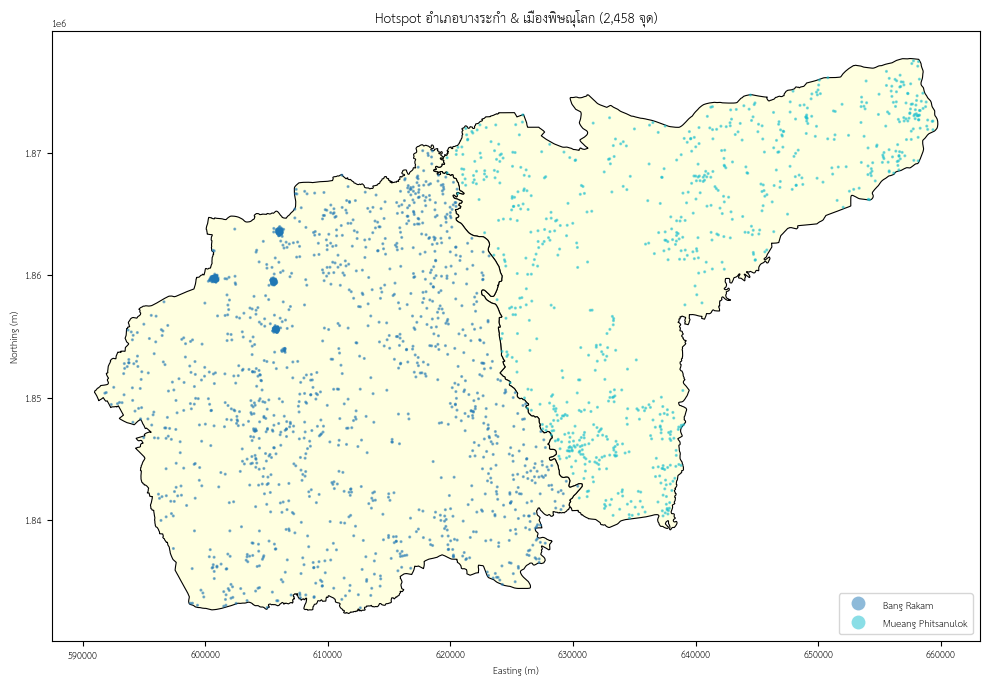

✓ Plot ตรวจสอบ 2 อำเภอสำเร็จ → checkpoint5b_2amphoe.png


In [88]:
# อัปเดต boundary ให้แสดงแค่ 2 อำเภอด้วย (สำหรับ Plot ขั้นต่อไป)
phitsanulok_amphoe_2 = phitsanulok_amphoe[phitsanulok_amphoe[AMPHOE_COL].isin(TARGET_AMPHOE)].copy()

fig, ax = plt.subplots(figsize=(10, 8))
phitsanulok_amphoe_2.plot(ax=ax, color='lightyellow', edgecolor='black', linewidth=0.8)
gdf_utm.plot(ax=ax, column='amphoe', markersize=1.5, alpha=0.5, legend=True,
             legend_kwds={'loc': 'lower right', 'fontsize': 10})
ax.set_title(f'Hotspot อำเภอบางระกำ & เมืองพิษณุโลก ({len(gdf_utm):,} จุด)', fontsize=14)
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '2amphoe.png'), dpi=150)
plt.show()
print("✓ Plot ตรวจสอบ 2 อำเภอสำเร็จ → checkpoint5b_2amphoe.png")

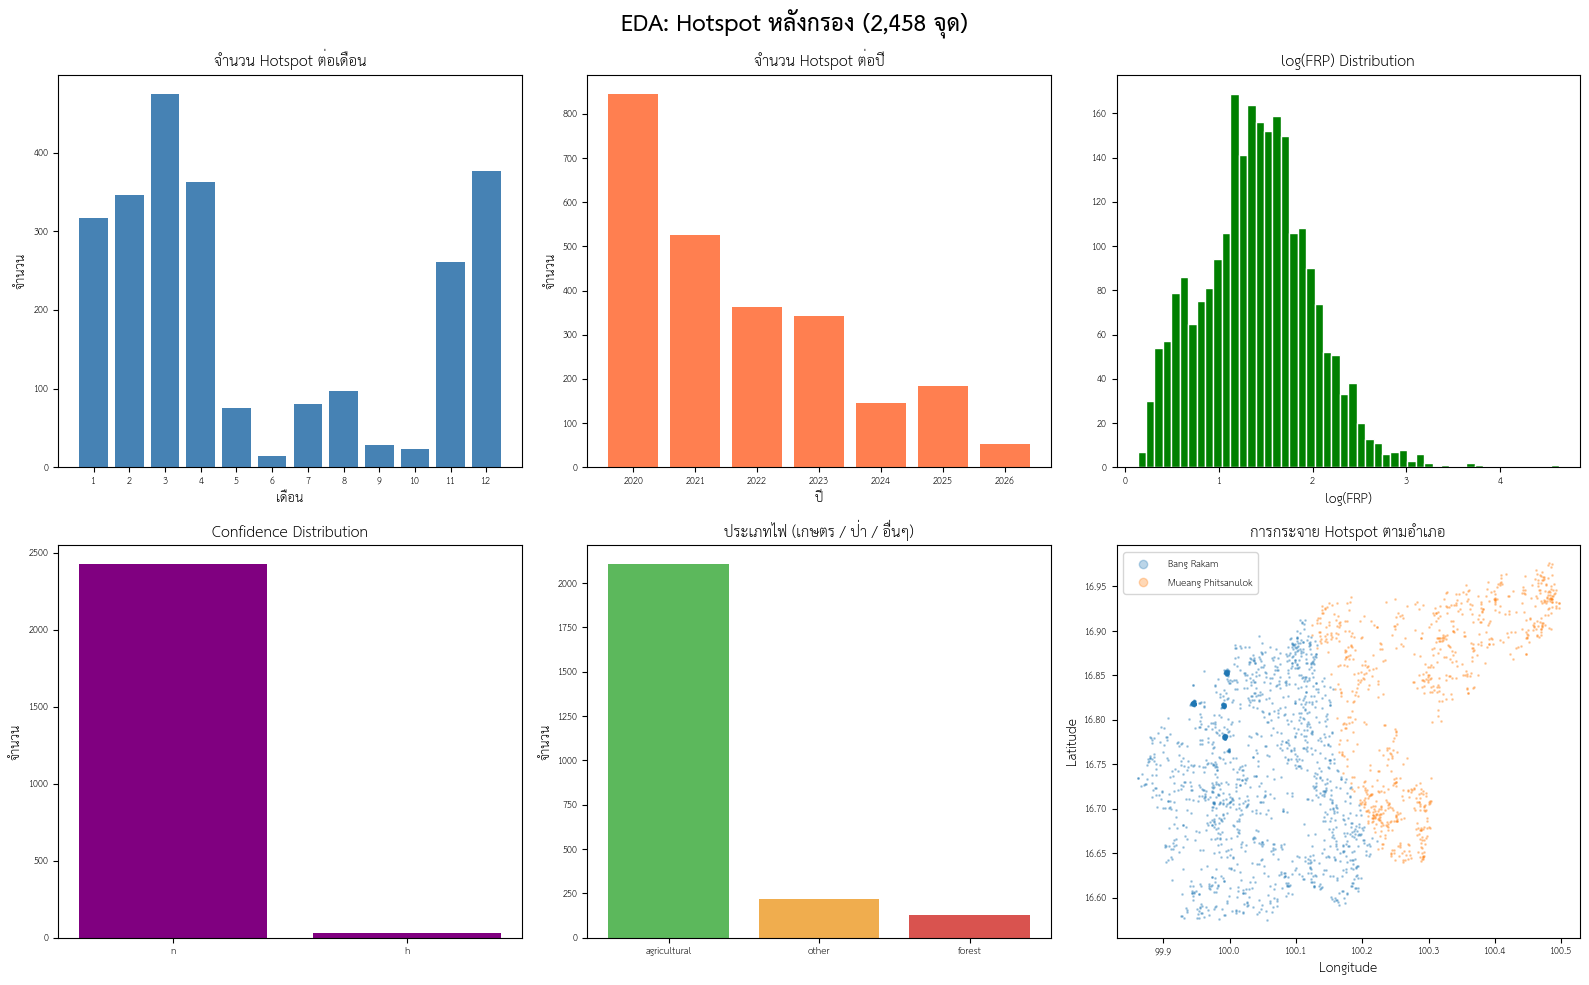

In [89]:
# EDA หลังกรองทั้งหมด — ข้อมูลชุดนี้คือชุดที่จะเข้าสู่ ST-DBSCAN จริง
# (เทียบกับ eda_raw ที่เป็น "ก่อนกรอง")
df_eda = gdf_utm.copy()
df_eda['acq_date'] = pd.to_datetime(df_eda['acq_date'])
df_eda['month'] = df_eda['acq_date'].dt.month
df_eda['year']  = df_eda['acq_date'].dt.year

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(f'EDA: Hotspot หลังกรอง ({len(df_eda):,} จุด)', fontsize=24, fontweight='bold')

# 1. Hotspot ต่อเดือน
m = df_eda['month'].value_counts().sort_index()
axes[0,0].bar(m.index, m.values, color='steelblue')
axes[0,0].set_title('จำนวน Hotspot ต่อเดือน', fontsize=16)
axes[0,0].set_xlabel('เดือน', fontsize=14)
axes[0,0].set_ylabel('จำนวน', fontsize=14)
axes[0,0].set_xticks(range(1, 13))

# 2. Hotspot ต่อปี
y = df_eda['year'].value_counts().sort_index()
axes[0,1].bar(y.index, y.values, color='coral')
axes[0,1].set_title('จำนวน Hotspot ต่อปี', fontsize=16)
axes[0,1].set_xlabel('ปี', fontsize=14)
axes[0,1].set_ylabel('จำนวน', fontsize=14)

# 3. log(FRP) distribution
axes[0,2].hist(df_eda['log_frp'], bins=50, color='green', edgecolor='white')
axes[0,2].set_title('log(FRP) Distribution', fontsize=16)
axes[0,2].set_xlabel('log(FRP)', fontsize=14)

# 4. Confidence distribution
conf = df_eda['confidence'].value_counts()
axes[1,0].bar(conf.index.astype(str), conf.values, color='purple')
axes[1,0].set_title('Confidence Distribution', fontsize=16)
axes[1,0].set_ylabel('จำนวน', fontsize=14)

# 5. ประเภทไฟ (เกษตร / ป่า / อื่นๆ)
ft = df_eda['fire_type'].value_counts()
ft_colors = {'agricultural':'#5cb85c','forest':'#d9534f','other':'#f0ad4e'}
axes[1,1].bar(ft.index, ft.values, color=[ft_colors.get(k,'#888888') for k in ft.index])
axes[1,1].set_title('ประเภทไฟ (เกษตร / ป่า / อื่นๆ)', fontsize=16)
axes[1,1].set_ylabel('จำนวน', fontsize=14)

# 6. การกระจายเชิงพื้นที่ แยกตามอำเภอ
for amp, sub in df_eda.groupby('amphoe'):
    axes[1,2].scatter(sub['longitude'], sub['latitude'], s=1, alpha=0.3, label=amp)
axes[1,2].set_title('การกระจาย Hotspot ตามอำเภอ', fontsize=16)
axes[1,2].set_xlabel('Longitude', fontsize=14)
axes[1,2].set_ylabel('Latitude', fontsize=14)
axes[1,2].legend(markerscale=6, fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'eda_filtered.png'), dpi=150, bbox_inches='tight')
plt.show()

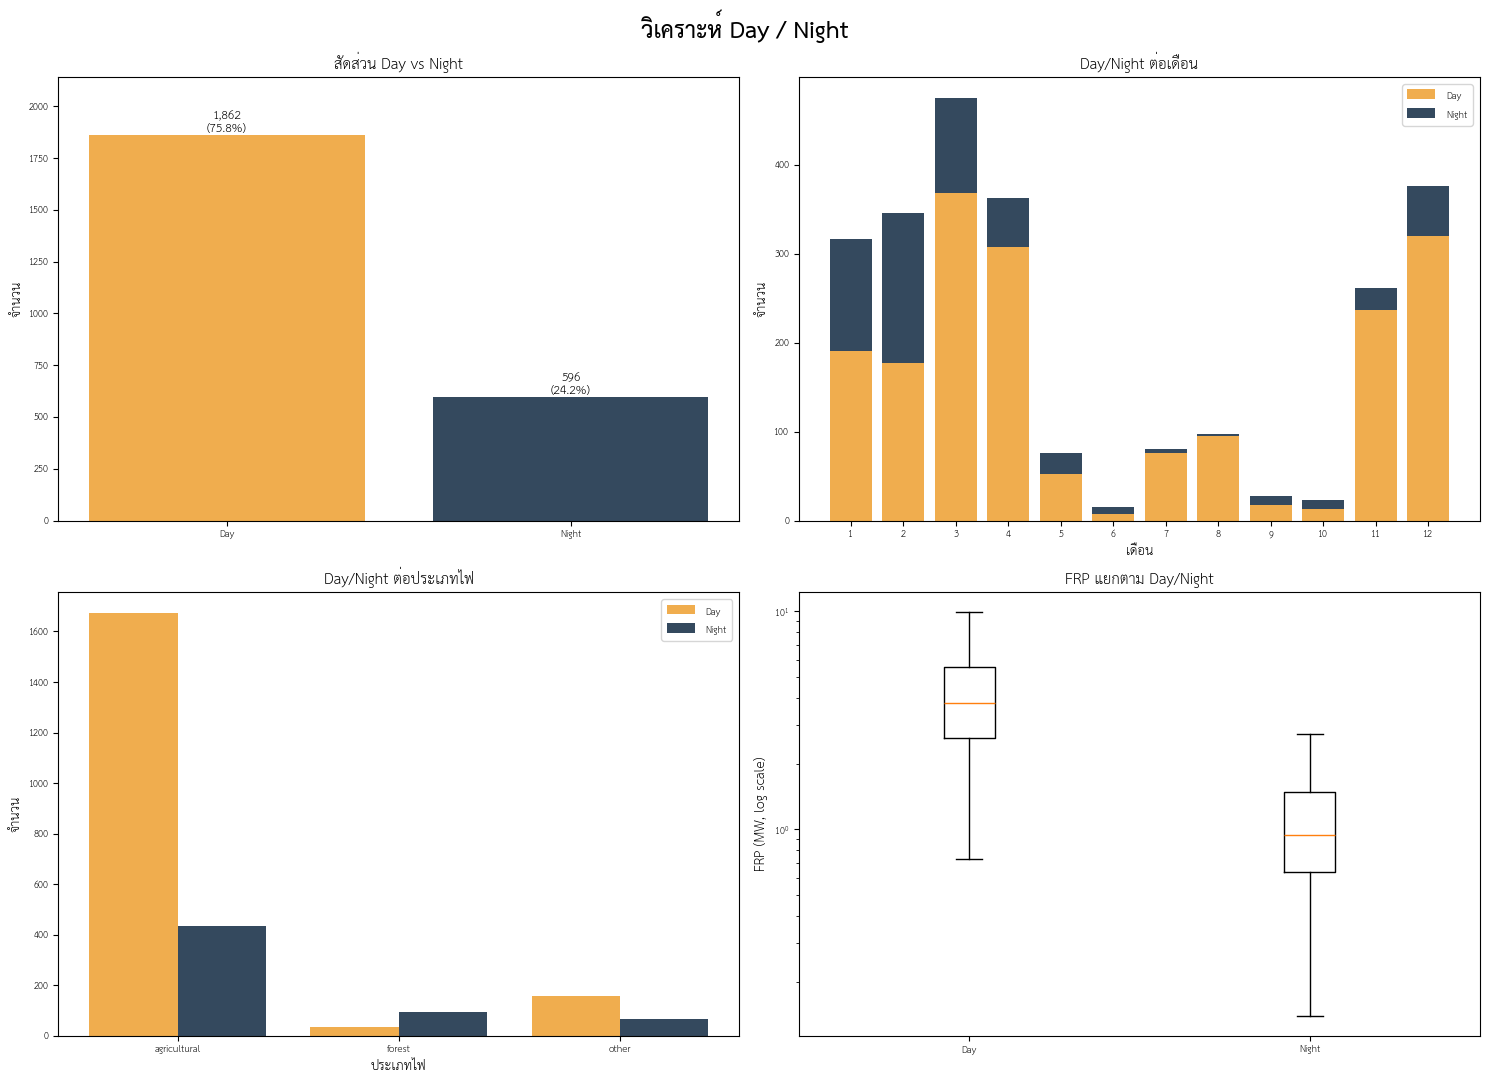


[CHECKPOINT EDA] EDA หลังกรอง
✓ ข้อมูลหลังกรองทั้งหมด: 2,458 จุด

สัดส่วน Day/Night:
_dn
Day      1862
Night     596

สัดส่วน Day/Night ในแต่ละประเภทไฟ (%):
_dn            Day  Night
fire_type                
agricultural  79.3   20.7
forest        26.4   73.6
other         70.6   29.4

FRP (count / mean / median) แยกตาม Day/Night:
       count  mean  median
_dn                       
Day     1862  4.70    3.78
Night    596  1.27    0.94

✓ บันทึกกราฟ → eda_filtered.png, eda_daynight.png


In [90]:
# ── วิเคราะห์ Day / Night ──────────────────────────────────────────────────
# สร้าง daynight_label จาก daynight (D/N) ที่มาจากข้อมูลดิบ NASA FIRMS
df_eda['daynight_label'] = (
    df_eda['daynight'].astype(str).str.strip().str.upper()
    .map({'D': 'Day', 'N': 'Night'}).fillna('Unknown')
)
df_eda['is_day'] = df_eda['daynight_label'].map({'Day': 1, 'Night': 0, 'Unknown': 0})
df_eda['_dn']   = df_eda['daynight_label']   # alias สำหรับ pivot table ด้านล่าง
gdf_utm['daynight_label'] = gdf_utm.index.map(df_eda['daynight_label'])
gdf_utm['is_day']         = gdf_utm.index.map(df_eda['is_day'])

palette = {'Day': '#f0ad4e', 'Night': '#34495e', 'Unknown': '#bbbbbb'}
order = [k for k in ['Day', 'Night', 'Unknown'] if (df_eda['_dn'] == k).any()]

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('วิเคราะห์ Day / Night', fontsize=24, fontweight='bold')

# 1. สัดส่วน Day vs Night
dn = df_eda['_dn'].value_counts().reindex(order)
axes[0,0].bar(dn.index, dn.values, color=[palette[k] for k in dn.index])
for idx, v in enumerate(dn.values):
    axes[0,0].text(idx, v, f'{int(v):,}\n({v/len(df_eda)*100:.1f}%)',
                   ha='center', va='bottom', fontsize=13)
axes[0,0].set_ylim(0, dn.max() * 1.15)
axes[0,0].set_title('สัดส่วน Day vs Night', fontsize=16)
axes[0,0].set_ylabel('จำนวน', fontsize=14)

# 2. Day/Night ต่อเดือน (stacked)
piv = (df_eda.pivot_table(index='month', columns='_dn',
                          values='latitude', aggfunc='count')
       .reindex(range(1, 13)).fillna(0))
bottom = np.zeros(len(piv))
for k in order:
    if k in piv.columns:
        axes[0,1].bar(piv.index, piv[k].values, bottom=bottom,
                      color=palette[k], label=k)
        bottom += piv[k].values
axes[0,1].set_title('Day/Night ต่อเดือน', fontsize=16)
axes[0,1].set_xlabel('เดือน', fontsize=14)
axes[0,1].set_ylabel('จำนวน', fontsize=14)
axes[0,1].set_xticks(range(1, 13))
axes[0,1].legend()

# 3. Day/Night ต่อประเภทไฟ
piv2 = (df_eda.pivot_table(index='fire_type', columns='_dn',
                           values='latitude', aggfunc='count').fillna(0))
piv2 = piv2[[k for k in order if k in piv2.columns]]
x = np.arange(len(piv2.index))
w = 0.8 / max(len(piv2.columns), 1)
for j, k in enumerate(piv2.columns):
    axes[1,0].bar(x + j*w, piv2[k].values, width=w,
                  color=palette[k], label=k)
axes[1,0].set_xticks(x + w*(len(piv2.columns)-1)/2)
axes[1,0].set_xticklabels(piv2.index, rotation=0)
axes[1,0].set_title('Day/Night ต่อประเภทไฟ', fontsize=16)
axes[1,0].set_xlabel('ประเภทไฟ', fontsize=14)
axes[1,0].set_ylabel('จำนวน', fontsize=14)
axes[1,0].legend(title='')

# 4. FRP แยกตาม Day/Night (log scale)
data_box = [df_eda.loc[df_eda['_dn'] == k, 'frp'].values for k in order]
bp = axes[1,1].boxplot(data_box, showfliers=False)
axes[1,1].set_xticklabels(order)
axes[1,1].set_yscale('log')
axes[1,1].set_title('FRP แยกตาม Day/Night', fontsize=16)
axes[1,1].set_ylabel('FRP (MW, log scale)', fontsize=14)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'eda_daynight.png'), dpi=150, bbox_inches='tight')
plt.show()

# สรุปเชิงตัวเลข
print("\n[CHECKPOINT EDA] EDA หลังกรอง")
print(f"✓ ข้อมูลหลังกรองทั้งหมด: {len(df_eda):,} จุด")
print("\nสัดส่วน Day/Night:")
print(df_eda['_dn'].value_counts().to_string())
print("\nสัดส่วน Day/Night ในแต่ละประเภทไฟ (%):")
print((df_eda.groupby('fire_type')['_dn']
       .value_counts(normalize=True).mul(100).round(1)
       .unstack().fillna(0)).to_string())
print("\nFRP (count / mean / median) แยกตาม Day/Night:")
print(df_eda.groupby('_dn')['frp']
      .agg(['count', 'mean', 'median']).round(2).to_string())
print("\n✓ บันทึกกราฟ → eda_filtered.png, eda_daynight.png")

In [ ]:
# คำนวณ dist_agri_m และ dist_forest_m

# ดึงเฉพาะ polygon เกษตรและป่า
agri_poly   = landuse[landuse['LUL1_CODE'] == 'A'][['geometry']].copy()
forest_poly = landuse[landuse['LUL1_CODE'] == 'F'][['geometry']].copy()

agri_union   = agri_poly.dissolve().reset_index(drop=True)
forest_union = forest_poly.dissolve().reset_index(drop=True)

# คำนวณระยะห่าง
gdf_utm['dist_agri_m']   = gdf_utm.geometry.apply(lambda pt: agri_union.distance(pt).min())
gdf_utm['dist_forest_m'] = gdf_utm.geometry.apply(lambda pt: forest_union.distance(pt).min())

print(f"dist_agri_m   range: {gdf_utm['dist_agri_m'].min():.1f} - {gdf_utm['dist_agri_m'].max():.1f} m")
print(f"dist_forest_m range: {gdf_utm['dist_forest_m'].min():.1f} - {gdf_utm['dist_forest_m'].max():.1f} m")
print(f"\nจุดที่อยู่ในเกษตร (dist_agri=0)  : {(gdf_utm['dist_agri_m'] == 0).sum():,} จุด")
print(f"จุดที่อยู่ในป่า (dist_forest=0)   : {(gdf_utm['dist_forest_m'] == 0).sum():,} จุด")

dist_agri_m   range: 0.0 - 2567.2 m
dist_forest_m range: 0.0 - 10973.1 m

จุดที่อยู่ในเกษตร (dist_agri=0)  : 1,777 จุด
จุดที่อยู่ในป่า (dist_forest=0)   : 129 จุด


In [92]:
print("\n[CHECKPOINT 5.5] ตรวจสอบการกรอง 2 อำเภอ")
assert len(gdf_utm) > 0, "✗ ไม่มีข้อมูลหลังกรอง"
assert set(gdf_utm['amphoe'].dropna().unique()).issubset(set(TARGET_AMPHOE)), \
    "✗ ยังมีอำเภออื่นหลงเหลืออยู่"
assert gdf_utm['amphoe'].nunique() == 2, \
    f"✗ พบ {gdf_utm['amphoe'].nunique()} อำเภอ ควรได้แค่ 2"
print(f"✓ เหลือ {len(gdf_utm):,} จุด")
print(f"✓ มีแค่ 2 อำเภอ: {sorted(gdf_utm['amphoe'].unique())}")


[CHECKPOINT 5.5] ตรวจสอบการกรอง 2 อำเภอ
✓ เหลือ 2,458 จุด
✓ มีแค่ 2 อำเภอ: ['Bang Rakam', 'Mueang Phitsanulok']


### **ตรวจสอบรวมหลัง Pipeline ทั้งหมด**

In [93]:
key_cols = [
    # ── พิกัดและเวลา ──────────────────────────────────
    'latitude', 'longitude', 'x_utm', 'y_utm',
    'acq_date', 't_days', 'month', 'month_sin', 'month_cos', 'burn_season',
    # ── ความรุนแรง ────────────────────────────────────
    'frp', 'log_frp', 'brightness', 'confidence',
    # ── กลางวัน/กลางคืน ──────────────────────────────
    'daynight_label', 'is_day',
    # ── ประเภทที่ดินและไฟ ─────────────────────────────
    'land_use_type', 'LU_CODE', 'LUL1_CODE',
    'is_agri', 'is_forest', 'fire_type', 'fire_type_detail',
    # ── ระยะห่าง ──────────────────────────────────────
    'dist_agri_m', 'dist_forest_m',
    # ── พื้นที่ ───────────────────────────────────────
    'amphoe',
]

print("Missing values ของ column สำคัญ:")
all_ok = True
for col in key_cols:
    if col in gdf_utm.columns:
        n_miss = gdf_utm[col].isnull().sum()
        pct    = n_miss / len(gdf_utm) * 100
        status = "✓" if n_miss == 0 else "⚠"
        print(f"  {status} {col}: {n_miss:,} ({pct:.1f}%)")
        if n_miss > 0:
            all_ok = False

print(f"\n{'─'*40}")
print(f"สรุปผลลัพธ์ Phase 1:")
print(f"{'─'*40}")
print(f"  Hotspot ทั้งหมด         : {len(gdf_utm):,} จุด")
print(f"  ในพื้นที่เกษตร (is_agri)  : {gdf_utm['is_agri'].sum():,} จุด ({gdf_utm['is_agri'].mean()*100:.1f}%)")
print(f"  ในพื้นที่ป่าไม้ (is_forest): {gdf_utm['is_forest'].sum():,} จุด ({gdf_utm['is_forest'].mean()*100:.1f}%)")
print(f"  อื่นๆ                      : {(~gdf_utm['is_agri'] & ~gdf_utm['is_forest']).sum():,} จุด")
print(f"  ช่วงเวลา                : {gdf_utm['acq_date'].min().date()} ถึง {gdf_utm['acq_date'].max().date()}")
print(f"  FRP เฉลี่ย              : {gdf_utm['frp'].mean():.2f} MW")
print(f"  FRP มัธยฐาน             : {gdf_utm['frp'].median():.2f} MW")
print(f"  จำนวน column            : {len(gdf_utm.columns)}")

Missing values ของ column สำคัญ:
  ✓ latitude: 0 (0.0%)
  ✓ longitude: 0 (0.0%)
  ✓ x_utm: 0 (0.0%)
  ✓ y_utm: 0 (0.0%)
  ✓ acq_date: 0 (0.0%)
  ✓ t_days: 0 (0.0%)
  ✓ month: 0 (0.0%)
  ✓ month_sin: 0 (0.0%)
  ✓ month_cos: 0 (0.0%)
  ✓ burn_season: 0 (0.0%)
  ✓ frp: 0 (0.0%)
  ✓ log_frp: 0 (0.0%)
  ✓ brightness: 0 (0.0%)
  ✓ confidence: 0 (0.0%)
  ✓ daynight_label: 0 (0.0%)
  ✓ is_day: 0 (0.0%)
  ✓ land_use_type: 0 (0.0%)
  ⚠ LU_CODE: 3 (0.1%)
  ⚠ LUL1_CODE: 3 (0.1%)
  ✓ is_agri: 0 (0.0%)
  ✓ is_forest: 0 (0.0%)
  ✓ fire_type: 0 (0.0%)
  ✓ fire_type_detail: 0 (0.0%)
  ✓ dist_agri_m: 0 (0.0%)
  ✓ dist_forest_m: 0 (0.0%)
  ✓ amphoe: 0 (0.0%)

────────────────────────────────────────
สรุปผลลัพธ์ Phase 1:
────────────────────────────────────────
  Hotspot ทั้งหมด         : 2,458 จุด
  ในพื้นที่เกษตร (is_agri)  : 2,108 จุด (85.8%)
  ในพื้นที่ป่าไม้ (is_forest): 129 จุด (5.2%)
  อื่นๆ                      : 221 จุด
  ช่วงเวลา                : 2020-01-01 ถึง 2026-04-08
  FRP เฉลี่ย           

In [94]:
# ══════════════════════════════════════════════════════════════════
#  Export — บันทึกเป็น GeoPackage พร้อมส่งต่อ Phase 2
# ══════════════════════════════════════════════════════════════════

# ── 1. ตรวจสอบและเติม columns daynight ที่อาจขาด ──────────────────
if 'daynight_label' not in gdf_utm.columns:
    gdf_utm['daynight_label'] = (
        gdf_utm['daynight'].astype(str).str.strip().str.upper()
        .map({'D': 'Day', 'N': 'Night'}).fillna('Unknown')
    )
if 'is_day' not in gdf_utm.columns:
    gdf_utm['is_day'] = gdf_utm['daynight_label'].map(
        {'Day': 1, 'Night': 0, 'Unknown': 0}
    )

# ── 2. เลือก columns ที่ต้องการจัดเก็บ ────────────────────────────
cols_keep = [
    'latitude', 'longitude', 'x_utm', 'y_utm',
    'acq_date', 't_days', 'month',
    'month_sin', 'month_cos', 'burn_season',
    'frp', 'log_frp', 'brightness', 'confidence',
    'daynight_label', 'is_day',
    'land_use_type', 'LU_CODE', 'LUL1_CODE',
    'is_agri', 'is_forest', 'fire_type', 'fire_type_detail',
    'dist_agri_m', 'dist_forest_m',
    'amphoe', 'geometry',
]
cols_keep  = [c for c in cols_keep if c in gdf_utm.columns]
gdf_final  = gdf_utm[cols_keep].copy()

# ── 3. บันทึกไฟล์ ──────────────────────────────────────────────────
gdf_final.to_file(PATH_OUTPUT, driver='GPKG', mode='w')

# ── 4. ตรวจสอบก่อนส่งต่อ Phase 2 ─────────────────────────────────
print("[CHECKPOINT FINAL] ตรวจสอบก่อนส่งต่อ Phase 2")
assert os.path.exists(PATH_OUTPUT), "✗ ไม่พบไฟล์ output"
gdf_verify = gpd.read_file(PATH_OUTPUT)
assert len(gdf_verify) == len(gdf_final), (
    f"✗ จำนวนแถวไม่ตรง (ต้นฉบับ {len(gdf_final)}, บันทึก {len(gdf_verify)})")
assert len(gdf_verify.columns) == len(gdf_final.columns), (
    f"✗ จำนวนคอลัมน์ไม่ตรง (ต้นฉบับ {len(gdf_final.columns)}, บันทึก {len(gdf_verify.columns)})")

print(f"✓ บันทึกไฟล์สำเร็จ: {PATH_OUTPUT}")
print(f"✓ {len(gdf_verify):,} แถว | {len(gdf_verify.columns)} columns | CRS: {gdf_verify.crs}")
print()
print("=" * 60)
print("Phase 1 เสร็จสมบูรณ์  →  พร้อมเข้า Phase 2: ST-DBSCAN")
print("=" * 60)


[CHECKPOINT FINAL] ตรวจสอบก่อนส่งต่อ Phase 2
✓ บันทึกไฟล์สำเร็จ: D:\gistnu\ST-DBSCAN\file_final\Phase 1 Final\hotspot_final.gpkg
✓ 2,458 แถว | 27 columns | CRS: EPSG:32647

Phase 1 เสร็จสมบูรณ์  →  พร้อมเข้า Phase 2: ST-DBSCAN
